# Boosting Modeling

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sys
import os

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().drop('PID', axis = 1).dropna() # load data from files

# split data into X and y

X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]].dropna()
y = (df["AD"] > df["ADPass"]).dropna()

# scale X
scale = StandardScaler()
scaled_X = scale.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 4)

In [24]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
abc = AdaBoostClassifier(algorithm="SAMME")
param_grid = {
    'learning_rate':[0.001,0.01,0.05,0.1],
    'n_estimators':[5,25,125,625],
    "estimator":[RidgeClassifier(), LogisticRegression(),DecisionTreeClassifier(max_depth=2)]
}

grid_abc = GridSearchCV(abc, param_grid, cv=10)
grid_abc.fit(X_train, y_train)


final = AdaBoostClassifier(algorithm = "SAMME", n_estimators=grid_abc.best_params_["n_estimators"],
                                    learning_rate=grid_abc.best_params_["learning_rate"], estimator = grid_abc.best_params_["estimator"]  )
final.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.1, n_estimators=625)

## Results

Training ROC AUC 0.6680312441182006


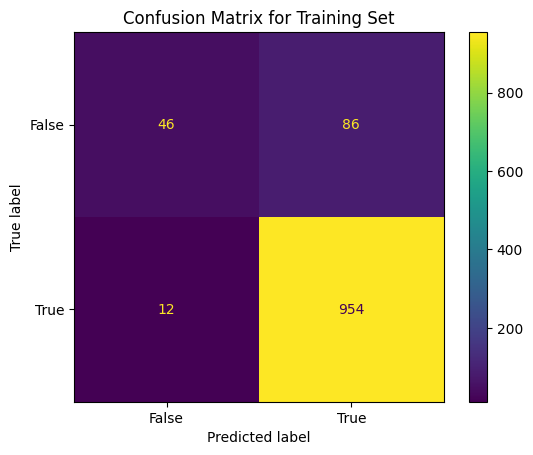

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

pred_boosting = final.predict(X_train)

print("Training ROC AUC", roc_auc_score(y_train, pred_boosting))
cm1 = ConfusionMatrixDisplay.from_predictions(y_train, pred_boosting)
cm1.ax_.set_title("Confusion Matrix for Training Set")
plt.show()

Testing ROC AUC 0.6337936987483814


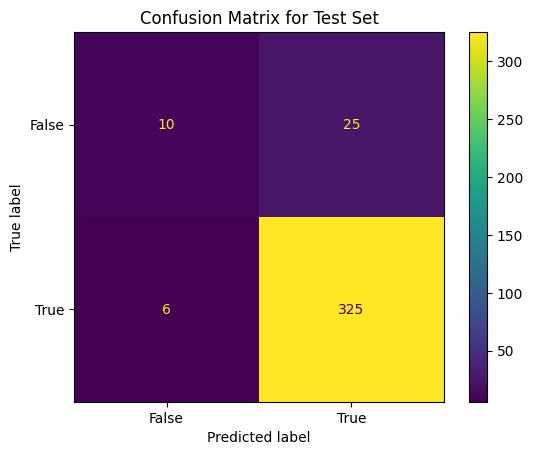

In [28]:
pred_boosting = final.predict(X_test)

print("Testing ROC AUC", roc_auc_score(y_test, pred_boosting))
cm1 = ConfusionMatrixDisplay.from_predictions(y_test, pred_boosting)
cm1.ax_.set_title("Confusion Matrix for Test Set")
plt.show()

## Interpretability

In [29]:
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

In [30]:
ebm = ExplainableBoostingClassifier()
ebm.fit(X_train, y_train)
show(ebm.explain_global())

<!-- http://127.0.0.1:7001/2148525410832/ -->

In [31]:
show(ebm.explain_local(X_test[:5], y_test[:5]), 0)

<!-- http://127.0.0.1:7001/2148550682448/ -->